# Module 5 Lab 2
Import new data, clean it, log changes and why, create a bar chart for housing type. Hint from textbook - Be sure to remove the "NA" type.

In [1]:
import pandas as pd
originaldf = pd.read_csv("custdata.tsv", sep="\t")
df = originaldf

In [2]:
df.shape

(1000, 11)

In [3]:
df.head()

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        1000 non-null   int64  
 1   sex           1000 non-null   str    
 2   is.employed   672 non-null    object 
 3   income        1000 non-null   int64  
 4   marital.stat  1000 non-null   str    
 5   health.ins    1000 non-null   bool   
 6   housing.type  944 non-null    str    
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           1000 non-null   float64
 10  state.of.res  1000 non-null   str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 115.8+ KB


In [5]:
df.isnull().sum()

custid            0
sex               0
is.employed     328
income            0
marital.stat      0
health.ins        0
housing.type     56
recent.move      56
num.vehicles     56
age               0
state.of.res      0
dtype: int64

<Axes: >

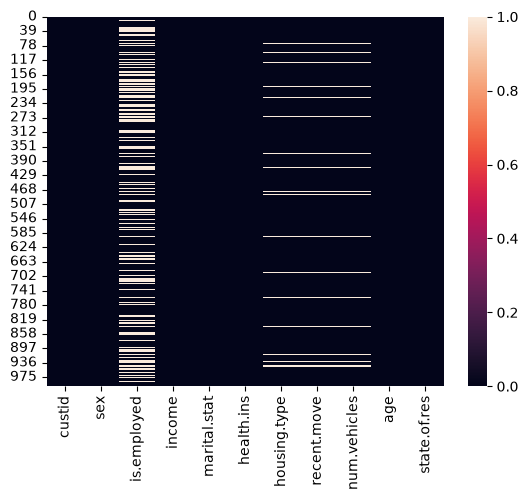

In [6]:
import seaborn as sns
sns.heatmap(df.isnull())

In [7]:
df.describe()

,custid,income,num.vehicles,age
count,1.000000e+03,1000.000000,944.000000,1000.000000
mean,6.984997e+05,53504.771000,1.916314,51.699815
std,4.135083e+05,65478.065729,1.101618,18.863433
min,2.068000e+03,-8700.000000,0.000000,0.000000
25%,3.456668e+05,14600.000000,1.000000,38.000000
50%,6.934030e+05,35000.000000,2.000000,50.000000
75%,1.044606e+06,67000.000000,2.000000,64.000000
max,1.414286e+06,615000.000000,6.000000,146.680197


In [8]:
print(df["housing.type"].value_counts())

housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
Occupied with no rent            11
Name: count, dtype: int64


# Data set description and issues to address.

We have a data set with 1000 rows/series and 11 columns. 

Housing Type: Housing type only has 944 non-null values (these rows are also missing recent move and number of vehicles, as seen on heatmap). Since we are sorting our data based on housing type, I will drop these 56 rows for the purpose of this exercise. The original dataset will be saved as originaldf. The working data frame will be df.

Income: We have a negative minimum income value which needs to be investigated. The max is not outside expected range.

Age: The minimum age is zero and needs to be investigated. The maximum age is 146 and cannot be. 

Is Employed: We are missing 328 "is employed" boolean responses.


# Housing Type is of key interest to us so we will drop the 56 out of 1000 rows that do not have housing type data. 

In [9]:
df=df.dropna(subset = ["housing.type"])

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 944 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        944 non-null    int64  
 1   sex           944 non-null    str    
 2   is.employed   664 non-null    object 
 3   income        944 non-null    int64  
 4   marital.stat  944 non-null    str    
 5   health.ins    944 non-null    bool   
 6   housing.type  944 non-null    str    
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           944 non-null    float64
 10  state.of.res  944 non-null    str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 117.8+ KB


# Address age issues - too young and too old

In [11]:
df[df["age"]<20]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
621,871562,M,True,37000,Never Married,False,Rented,True,2.0,19.0,Texas
635,886647,F,True,10600,Never Married,False,Rented,False,4.0,19.0,Georgia
667,931449,M,NaN,42400,Married,True,Homeowner free and clear,False,2.0,0.0,Missouri
677,953043,F,True,20000,Never Married,True,Rented,True,2.0,19.0,Texas
760,1057778,F,NaN,18000,Never Married,True,Rented,False,4.0,19.0,California
868,1229417,F,True,48000,Married,True,Homeowner with mortgage/loan,False,3.0,0.0,Washington
965,1375846,F,True,113950,Divorced/Separated,True,Rented,False,2.0,0.0,Louisiana


Age: There are three rows with zero, otherwise the minimum age is 19. 
Next decision is to drop or estimate. The three are in three different housing types. I could boxplot sort to see if estimating makes sense. 

<Axes: title={'center': 'age'}, xlabel='housing.type'>

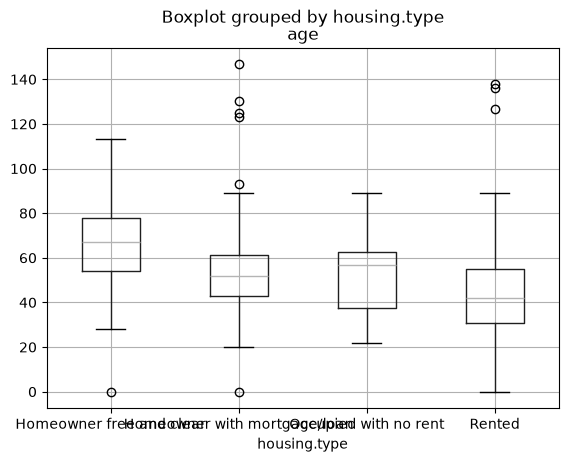

In [12]:
df.boxplot(column = 'age', by= 'housing.type')

In [13]:
# Many ages are outside of possible range. Need to see how many.
df[df["age"]>90]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
212,287882,M,True,60000,Married,True,Rented,True,2.0,137.700030,Florida
266,364991,F,NaN,12000,Divorced/Separated,True,Homeowner with mortgage/loan,False,1.0,123.061023,Nevada
286,397230,F,True,31200,Married,True,Rented,False,2.0,136.052160,Texas
330,459910,M,NaN,56300,Married,True,Homeowner free and clear,False,1.0,93.000000,California
593,843811,F,True,40000,Never Married,True,Homeowner with mortgage/loan,False,1.0,146.680197,Indiana
625,875771,M,False,175200,Married,True,Homeowner with mortgage/loan,False,3.0,124.845087,Arkansas
646,904144,F,NaN,5700,Widowed,True,Homeowner free and clear,False,1.0,93.000000,California
710,991794,M,NaN,14600,Married,True,Homeowner free and clear,False,1.0,93.000000,New Hampshire
711,991888,M,NaN,67000,Married,True,Homeowner free and clear,False,1.0,93.000000,South Dakota
752,1047534,M,True,200000,Married,True,Homeowner with mortgage/loan,False,4.0,130.401605,Washington


The maximum reasonable age is 93 (and there are 5 of them). There are 8 values above that ranging from 113 to 147.

We also have 3 rows with age listed as 0. 

There does seem to be a reasonable age mean for the different housing types, based on the boxplots. 

In [14]:
df.groupby("housing.type")["age"].mean().sort_values()

housing.type
Rented                          45.223872
Homeowner with mortgage/loan    52.783951
Occupied with no rent           54.090909
Homeowner free and clear        65.104059
Name: age, dtype: float64

In [15]:
df.groupby("housing.type")["age"].median().sort_values()

housing.type
Rented                          42.0
Homeowner with mortgage/loan    52.0
Occupied with no rent           57.0
Homeowner free and clear        67.0
Name: age, dtype: float64

# Substitute the anomolous ages with the mean age of the housing type category by location. 
The other data in those rows appear to be in order so I do not want to drop them. The median and mean are close which shows that the data are not skewed in a particular direction. I will use the mean in that case.

Mean age substitutions
+ Rented = 45
+ Homeowner with mortgage/loan = 53
+ Occupied with no rent = 54
+ Homeowner free and clear = 65


In [16]:
df[df["age"]<19]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
667,931449,M,NaN,42400,Married,True,Homeowner free and clear,False,2.0,0.0,Missouri
868,1229417,F,True,48000,Married,True,Homeowner with mortgage/loan,False,3.0,0.0,Washington
965,1375846,F,True,113950,Divorced/Separated,True,Rented,False,2.0,0.0,Louisiana


In [17]:
# Replace 0 ages with mean age for the corresponding housing type category
df.loc[667, "age"] = 65
df.loc[868, "age"] = 53
df.loc[965, "age"] = 45

In [18]:
df[df["age"]>100]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
212,287882,M,True,60000,Married,True,Rented,True,2.0,137.700030,Florida
266,364991,F,NaN,12000,Divorced/Separated,True,Homeowner with mortgage/loan,False,1.0,123.061023,Nevada
286,397230,F,True,31200,Married,True,Rented,False,2.0,136.052160,Texas
593,843811,F,True,40000,Never Married,True,Homeowner with mortgage/loan,False,1.0,146.680197,Indiana
625,875771,M,False,175200,Married,True,Homeowner with mortgage/loan,False,3.0,124.845087,Arkansas
752,1047534,M,True,200000,Married,True,Homeowner with mortgage/loan,False,4.0,130.401605,Washington
926,1303929,F,False,43400,Never Married,True,Rented,False,1.0,126.737284,West Virginia
953,1361012,F,NaN,255000,Widowed,True,Homeowner free and clear,False,1.0,113.337207,Tennessee


In [19]:
# Replace 8 ages over 100 with the mean age for the corresponding housing type category
df.loc[212, "age"] = 45
df.loc[266, "age"] = 53
df.loc[286, "age"] = 45
df.loc[593, "age"] = 53
df.loc[625, "age"] = 53
df.loc[752, "age"] = 53
df.loc[926, "age"] = 45
df.loc[953, "age"] = 65

In [20]:
# Cehck to see that age range is 19 to 93.
df.describe()

,custid,income,num.vehicles,age
count,9.440000e+02,944.000000,944.000000,944.000000
mean,6.987750e+05,56310.594280,1.916314,51.441737
std,4.140340e+05,66303.677254,1.101618,16.715852
min,2.068000e+03,-8700.000000,0.000000,19.000000
25%,3.430412e+05,17000.000000,1.000000,39.000000
50%,7.059435e+05,37200.000000,2.000000,50.000000
75%,1.044606e+06,70000.000000,2.000000,63.000000
max,1.414286e+06,615000.000000,6.000000,93.000000


# Income Issues

In [21]:
# Check the negative income
df[df["income"]<0]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
691,971703,M,False,-8700,Married,True,Homeowner with mortgage/loan,False,3.0,60.0,Oklahoma


This homeowner is unemployed and 60. Can move to 0 or assume positive income

In [22]:
df.groupby("is.employed")["income"].mean().sort_values()

is.employed
False    23177.397260
True     72206.389171
Name: income, dtype: float64

In [23]:
df.groupby("is.employed")["income"].median().sort_values()

is.employed
False    20900.0
True     50000.0
Name: income, dtype: float64

In [24]:
df.groupby("is.employed")["income"].min().sort_values()

is.employed
False   -8700
True       30
Name: income, dtype: int64

In [25]:
df.groupby("is.employed")["income"].max().sort_values()

is.employed
False    175200
True     615000
Name: income, dtype: int64

<Axes: title={'center': 'income'}, xlabel='is.employed'>

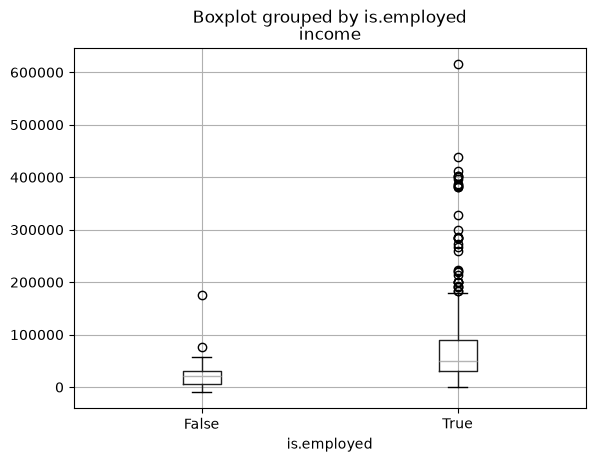

In [26]:
df.boxplot(column = 'income', by= 'is.employed')

In [27]:
df[(df["is.employed"]==False) & (df["income"]==0)]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
139,175572,F,False,0,Married,False,Rented,True,2.0,38.0,West Virginia
220,304200,F,False,0,Divorced/Separated,False,Homeowner with mortgage/loan,False,1.0,53.0,Indiana
339,465818,F,False,0,Married,False,Homeowner with mortgage/loan,False,3.0,33.0,Indiana
399,547258,M,False,0,Married,True,Rented,False,2.0,53.0,Massachusetts
484,674271,M,False,0,Married,True,Rented,True,1.0,54.0,Massachusetts
714,996953,F,False,0,Married,False,Rented,True,3.0,35.0,Georgia
892,1259643,F,False,0,Divorced/Separated,True,Rented,True,1.0,57.0,West Virginia
960,1369460,M,False,0,Never Married,False,Homeowner free and clear,False,3.0,50.0,North Dakota


In [28]:
df[df["income"]==0]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
44,53186,F,NaN,0,Married,True,Homeowner with mortgage/loan,False,2.0,61.0,Pennsylvania
46,53759,F,NaN,0,Married,True,Homeowner with mortgage/loan,False,2.0,34.0,Ohio
49,55992,F,NaN,0,Married,True,Rented,False,1.0,38.0,Colorado
50,56040,F,NaN,0,Married,True,Rented,True,2.0,39.0,California
114,141492,F,NaN,0,Married,True,Homeowner with mortgage/loan,False,3.0,34.0,Florida
117,147984,F,NaN,0,Married,True,Rented,False,1.0,49.0,Florida
119,149480,F,NaN,0,Married,False,Homeowner free and clear,False,2.0,46.0,New York
131,164576,F,NaN,0,Never Married,False,Rented,False,1.0,28.0,Texas
139,175572,F,False,0,Married,False,Rented,True,2.0,38.0,West Virginia


# Replace the negative income with positive.
For the one negative income, I will switch it to positive. Most unemployed have an income, whereas only 8 unemployed have no income. The income fits within the box plot range when flipped to positive.

In [29]:
# Using the code used in Module 3 Lab 1

df.loc[691, "income"] = 8700

In [30]:
print(df.loc[691])

custid                                971703
sex                                        M
is.employed                            False
income                                  8700
marital.stat                         Married
health.ins                              True
housing.type    Homeowner with mortgage/loan
recent.move                            False
num.vehicles                             3.0
age                                     60.0
state.of.res                        Oklahoma
Name: 691, dtype: object


# Is employed issues
There are 328 values missing. It's true or false. This data is not important to us at this time because we are using bar plots of housing type and this information is not vital for our current purpose. I will delete this column and rename the data frame as df_mod solution is to delete the column form the database such that all the other useful data is kept.

In [31]:
# Create modified data frame without the is.employed column. This works for the purpose of this problem.
df_mod = df.drop(columns='is.employed')

In [32]:
df_mod.shape

(944, 10)

# The bar chart

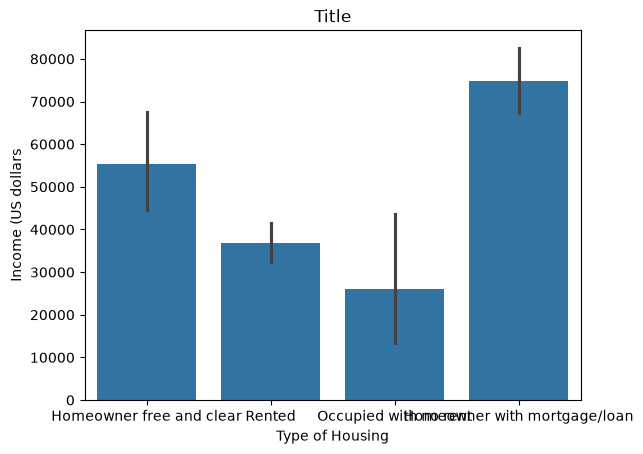

<Figure size 1000x600 with 0 Axes>

In [33]:
# Bar chart of average income by housing type

import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=df_mod, x="housing.type", y="income")
plt.title("Title")
plt.xlabel("Type of Housing")
plt.ylabel("Income (US dollars")
plt.figure(figsize=(10,6))
plt.savefig('chart.png',dpi=150)
plt.show()

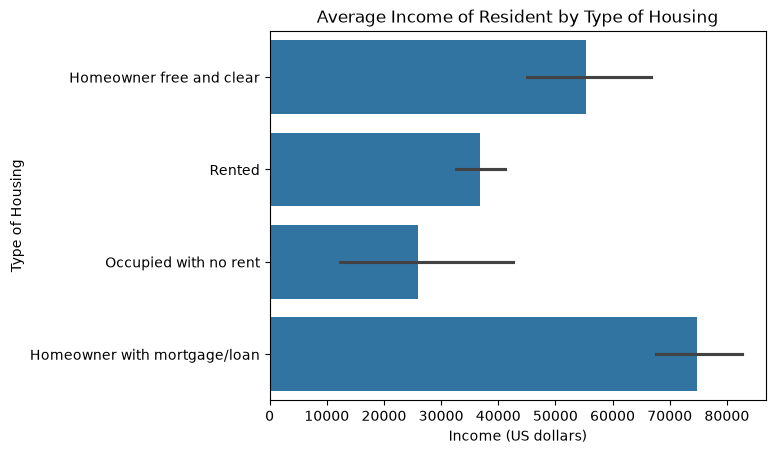

In [34]:
# Try horizontal by changing x and y for more room for "Type of Housing" text

import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=df_mod, x="income", y="housing.type")
plt.title("Average Income of Resident by Type of Housing")
plt.ylabel("Type of Housing")
plt.xlabel("Income (US dollars)")
plt.show()

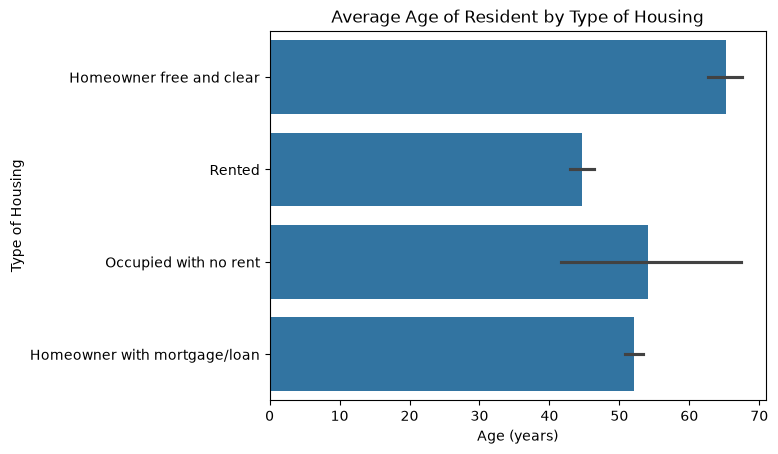

In [35]:
sns.barplot(data=df_mod, x="age", y="housing.type")
plt.title("Average Age of Resident by Type of Housing")
plt.ylabel("Type of Housing")
plt.xlabel("Age (years)")
plt.show()

# Summary of changes to dataset

The original data set (originaldf) was 1000 rows/series and 11 columns.
The final modified dataset (mod_df) is 944 rows/series and 10 columns.

Housing Type: Housing type had 944 non-null values and 56 null values (these rows are also missing recent move and number of vehicles, as seen on heatmap). 
+ Since we are sorting our data based on housing type, all 56 NA rows were dropped. The original dataset will be saved as originaldf. The working data frame at this point is called df.

Income: We have a negative minimum income value which needs to be investigated. The max is not outside expected range.
+ The negative income was -8700. The choices were delete, change to 0 (a not employed person)or switched to positive. The value was switched to +8700 after confiming that the majority of the not employed had an income (not 0) and 8700 was within the range of not employed income (0 to 175000).

Age: The minimum age is zero and needs to be investigated. The maximum age is 146 and cannot be.
+ The age minimum was determined to be 19 and the three rows with age 0 were anonymous. There were 8 ages above 93. 93 was considered to be the oldest, as there were 5 of them and the other 8 were between 113 and 146. In all cases, the mean age for the housing type age was input as the missing age. Note: this does bias the data towards the norm. These 8 out of 944 values are biased toward the norm. 

Is Employed: We are missing 328 "is employed" boolean responses. As we are making a bar graph with the categories of housing type, a boolean response is not an appropriate graphing partner. This column was considered extraneous for our purposes and excluded in a new data set called mod_df with 944 rows and 10 columns.

https://github.com/acamend/cs82a-portfolio